# Lab 1 Task 2

Датасет `diabetes_data.csv`: **8 ознак** (без `diabetes`) × **5 архітектур** × **5 активацій** × **7 оптимізаторів** → **525** рядків у `results_df`. Ціль — колонка **`diabetes`** (бінарна класифікація): мітки **one-hot** (`to_categorical`), модель з **`softmax`** на виході, **`categorical_crossentropy`** і **`accuracy`**; на тесті в таблиці — **`accuracy_test`** (остання `val_loss` — крос-ентропія на валідації).


In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"

from keras.utils import set_random_seed, to_categorical

set_random_seed(42)

import numpy as np
import pandas as pd
from keras.callbacks import EarlyStopping
from keras.layers import Dense
from keras.models import Sequential
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [2]:
df_2 = pd.read_csv("diabetes_data.csv")
df_2.head()


,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df_2.drop(columns=["diabetes"])
y = df_2["diabetes"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.22, random_state=42, stratify=y_temp
)

N_CLASSES = int(np.max(y.values)) + 1
y_train = to_categorical(np.asarray(y_train).astype(int).ravel(), num_classes=N_CLASSES)
y_val = to_categorical(np.asarray(y_val).astype(int).ravel(), num_classes=N_CLASSES)
y_test_int = np.asarray(y_test).astype(int).ravel()

X_train = np.asarray(X_train, dtype=np.float32)
X_val = np.asarray(X_val, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_val_std = std_scaler.transform(X_val)
X_test_std = std_scaler.transform(X_test)

feature_prep = Pipeline(
    [
        ("scale", StandardScaler()),
        ("normalize", MinMaxScaler(feature_range=(0, 1))),
    ]
)
X_train_sn = feature_prep.fit_transform(X_train)
X_val_sn = feature_prep.transform(X_val)
X_test_sn = feature_prep.transform(X_test)

X_train.shape, X_val.shape, X_test.shape, N_CLASSES


((538, 8), (153, 8), (77, 8), 2)

In [4]:
def build_small(n_cols: int, activation: str = "relu", n_classes: int = 2) -> Sequential:
    m = Sequential()
    m.add(Dense(10, activation=activation, input_shape=(n_cols,)))
    m.add(Dense(10, activation=activation))
    m.add(Dense(n_classes, activation="softmax"))
    return m


def build_mc(n_cols: int, activation: str = "relu", n_classes: int = 2) -> Sequential:
    m = Sequential()
    m.add(Dense(200, activation=activation, input_shape=(n_cols,)))
    m.add(Dense(200, activation=activation))
    m.add(Dense(200, activation=activation))
    m.add(Dense(n_classes, activation="softmax"))
    return m


def build_mc_lite(n_cols: int, activation: str = "relu", n_classes: int = 2) -> Sequential:
    m = Sequential()
    m.add(Dense(96, activation=activation, input_shape=(n_cols,)))
    m.add(Dense(96, activation=activation))
    m.add(Dense(96, activation=activation))
    m.add(Dense(n_classes, activation="softmax"))
    return m


def build_mc_heavy(n_cols: int, activation: str = "relu", n_classes: int = 2) -> Sequential:
    m = Sequential()
    m.add(Dense(320, activation=activation, input_shape=(n_cols,)))
    m.add(Dense(320, activation=activation))
    m.add(Dense(320, activation=activation))
    m.add(Dense(n_classes, activation="softmax"))
    return m


def build_mc_deep(n_cols: int, activation: str = "relu", n_classes: int = 2) -> Sequential:
    m = Sequential()
    m.add(Dense(200, activation=activation, input_shape=(n_cols,)))
    m.add(Dense(200, activation=activation))
    m.add(Dense(200, activation=activation))
    m.add(Dense(200, activation=activation))
    m.add(Dense(n_classes, activation="softmax"))
    return m


runs = [
    ("small_raw", "10-10-1", "без скейлінгу", build_small, X_train, X_val, X_test),
    ("mc_raw", "200-200-200-1", "без скейлінгу", build_mc, X_train, X_val, X_test),
    ("mc_lite_raw", "96-96-96-1", "без скейлінгу", build_mc_lite, X_train, X_val, X_test),
    ("mc_heavy_raw", "320-320-320-1", "без скейлінгу", build_mc_heavy, X_train, X_val, X_test),
    ("mc_deep_raw", "200-200-200-200-1", "без скейлінгу", build_mc_deep, X_train, X_val, X_test),
    (
        "small_std",
        "10-10-1",
        "тільки скейлінг (StandardScaler)",
        build_small,
        X_train_std,
        X_val_std,
        X_test_std,
    ),
    (
        "mc_std",
        "200-200-200-1",
        "тільки скейлінг (StandardScaler)",
        build_mc,
        X_train_std,
        X_val_std,
        X_test_std,
    ),
    (
        "mc_lite_std",
        "96-96-96-1",
        "тільки скейлінг (StandardScaler)",
        build_mc_lite,
        X_train_std,
        X_val_std,
        X_test_std,
    ),
    (
        "mc_heavy_std",
        "320-320-320-1",
        "тільки скейлінг (StandardScaler)",
        build_mc_heavy,
        X_train_std,
        X_val_std,
        X_test_std,
    ),
    (
        "mc_deep_std",
        "200-200-200-200-1",
        "тільки скейлінг (StandardScaler)",
        build_mc_deep,
        X_train_std,
        X_val_std,
        X_test_std,
    ),
    (
        "small_sn",
        "10-10-1",
        "скейлінг + нормалізація (StandardScaler + MinMax)",
        build_small,
        X_train_sn,
        X_val_sn,
        X_test_sn,
    ),
    (
        "mc_sn",
        "200-200-200-1",
        "скейлінг + нормалізація (StandardScaler + MinMax)",
        build_mc,
        X_train_sn,
        X_val_sn,
        X_test_sn,
    ),
    (
        "mc_lite_sn",
        "96-96-96-1",
        "скейлінг + нормалізація (StandardScaler + MinMax)",
        build_mc_lite,
        X_train_sn,
        X_val_sn,
        X_test_sn,
    ),
    (
        "mc_heavy_sn",
        "320-320-320-1",
        "скейлінг + нормалізація (StandardScaler + MinMax)",
        build_mc_heavy,
        X_train_sn,
        X_val_sn,
        X_test_sn,
    ),
    (
        "mc_deep_sn",
        "200-200-200-200-1",
        "скейлінг + нормалізація (StandardScaler + MinMax)",
        build_mc_deep,
        X_train_sn,
        X_val_sn,
        X_test_sn,
    ),
]

from keras.optimizers import SGD, RMSprop, Adam, Adadelta, Adagrad, Adamax, Nadam

ACTIVATIONS = ["relu", "tanh", "elu", "selu", "gelu"]

OPTIMIZERS = [
    ("SGD", lambda: SGD(learning_rate=0.01, momentum=0.9)),
    ("RMSprop", lambda: RMSprop()),
    ("Adam", lambda: Adam()),
    ("Adadelta", lambda: Adadelta()),
    ("Adagrad", lambda: Adagrad()),
    ("Adamax", lambda: Adamax()),
    ("Nadam", lambda: Nadam()),
]

rows = []
for model_id, arch, prep, builder, Xt, Xv, Xte in runs:
    n_cols = Xt.shape[1]
    for act in ACTIVATIONS:
        for opt_name, make_opt in OPTIMIZERS:
            model = builder(n_cols, activation=act, n_classes=N_CLASSES)
            model.compile(
                optimizer=make_opt(),
                loss="categorical_crossentropy",
                metrics=["accuracy"],
            )
            es = EarlyStopping(patience=3, monitor="val_loss")
            hist = model.fit(
                Xt,
                y_train,
                validation_data=(Xv, y_val),
                epochs=30,
                callbacks=[es],
                verbose=0,
            )
            y_proba = np.asarray(model.predict(Xte, verbose=0), dtype=np.float64)
            if np.isfinite(y_proba).all():
                y_pred_cls = np.argmax(y_proba, axis=1)
                acc = float(accuracy_score(y_test_int, y_pred_cls))
            else:
                acc = float("nan")

            vl = hist.history["val_loss"][-1]
            vl = float(vl) if np.isfinite(vl) else float("nan")
            va = hist.history["val_accuracy"][-1]
            va = float(va) if np.isfinite(va) else float("nan")
            rows.append(
                {
                    "model_id": model_id,
                    "оптимізатор": opt_name,
                    "активація": act,
                    "архітектура": arch,
                    "ознаки": prep,
                    "accuracy_test": acc,
                    "val_loss_остання_епоха": vl,
                    "val_accuracy_остання_епоха": va,
                }
            )

results_df = pd.DataFrame(rows)
results_df

top5_acc = results_df.dropna(subset=["accuracy_test"]).nlargest(5, "accuracy_test")
top5_acc


/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the mode

,model_id,оптимізатор,активація,архітектура,ознаки,accuracy_test,val_loss_остання_епоха,val_accuracy_остання_епоха
215,mc_std,Adamax,relu,200-200-200-1,тільки скейлінг (StandardScaler),0.818182,0.466594,0.771242
279,mc_lite_std,Nadam,gelu,96-96-96-1,тільки скейлінг (StandardScaler),0.818182,0.468769,0.764706
341,mc_deep_std,Adamax,selu,200-200-200-200-1,тільки скейлінг (StandardScaler),0.818182,0.477962,0.784314
391,mc_sn,Nadam,relu,200-200-200-1,скейлінг + нормалізація (StandardScaler + MinMax),0.818182,0.496028,0.784314
204,small_std,RMSprop,gelu,10-10-1,тільки скейлінг (StandardScaler),0.805195,0.480909,0.751634


/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


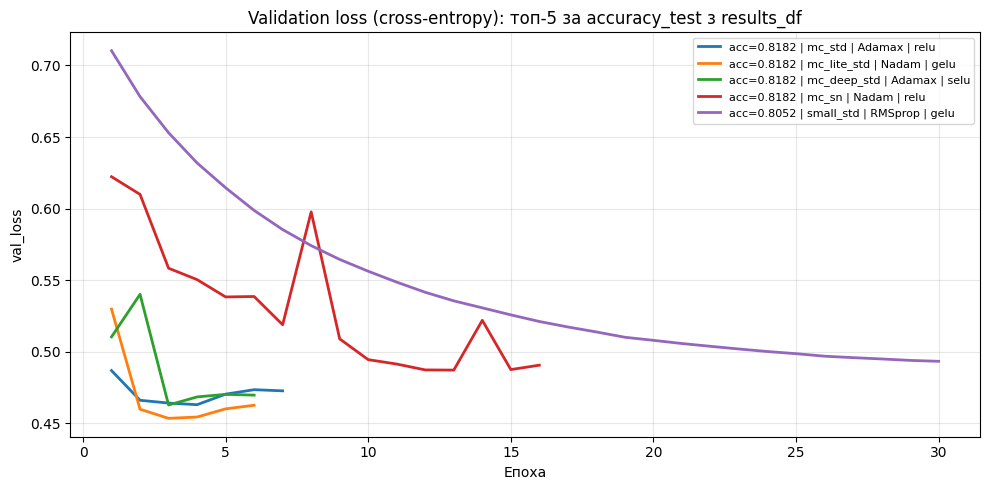

In [5]:
import matplotlib.pyplot as plt

top5 = results_df.dropna(subset=["accuracy_test"]).nlargest(5, "accuracy_test")
if len(top5) == 0:
    raise ValueError("Немає рядків зі скінченним accuracy_test — спочатку запусти клітину з повним навчанням.")

RUN_LOOKUP = {mid: (b, xt, xv, xte) for mid, _, _, b, xt, xv, xte in runs}
OPT_LOOKUP = {name: factory for name, factory in OPTIMIZERS}

PICKS = []
for _, row in top5.iterrows():
    mid = row["model_id"]
    opt = row["оптимізатор"]
    act = row["активація"]
    acc = row["accuracy_test"]
    builder, Xt, Xv, _ = RUN_LOOKUP[mid]
    make_opt = OPT_LOOKUP[opt]
    label = f"acc={float(acc):.4f} | {mid} | {opt} | {act}"
    PICKS.append((label, builder, act, make_opt, Xt, Xv))

base_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#17becf",
]
colors = [base_colors[i % len(base_colors)] for i in range(len(PICKS))]

fig, ax = plt.subplots(figsize=(10, 5))

for (label, builder, act, make_opt, Xt, Xv), color in zip(PICKS, colors):
    n_cols = Xt.shape[1]
    model = builder(n_cols, activation=act, n_classes=N_CLASSES)
    model.compile(
        optimizer=make_opt(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    es = EarlyStopping(patience=3, monitor="val_loss")
    hist = model.fit(
        Xt,
        y_train,
        validation_data=(Xv, y_val),
        epochs=30,
        callbacks=[es],
        verbose=0,
    )
    h = hist.history
    ep = np.arange(1, len(h["val_loss"]) + 1)
    ax.plot(ep, h["val_loss"], color=color, linewidth=2, label=label)

ax.set_title("Validation loss (cross-entropy): топ-5 за accuracy_test з results_df")
ax.set_xlabel("Епоха")
ax.set_ylabel("val_loss")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()
